In [7]:
import importlib
import jax
import jax.numpy as jnp
import pjax
import time
import numpy as np
import matplotlib.pyplot as plt
from data import MNISTDataModule

importlib.reload(pjax)


# Ensure reproducibility
key = jax.random.key(42)

print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")

JAX version: 0.6.2
Devices: [CpuDevice(id=0)]


## 1. Define Models with Single Conv Layer

In [8]:
from pjax import nn, optim
# Reload modules to pick up changes
importlib.reload(pjax.nn)
class FftConvModel(nn.Module):
    """Model with a single FftConv2D layer."""
    
    def __init__(self, height, width, in_channels, out_channels, kernel_size):
        super().__init__()
        self.conv = nn.FftConv2D(height, width, in_channels, out_channels, kernel_size)
    
    def __call__(self, x):
        return self.conv(x)


class RegularConvModel(nn.Module):
    """Model with a single Conv2D layer."""
    
    def __init__(self, in_channels, out_channels, kernel_size, padding="SAME"):
        super().__init__()
        self.conv = nn.Conv2D(in_channels, out_channels, kernel_shape=(kernel_size, kernel_size), padding=padding)
    
    def __call__(self, x):
        return self.conv(x)

## 2. Kernel Learning Benchmark
Generate a dataset by convolving a random kernel over random images, and compare how fast FftConv2D and Conv2D can learn this kernel.

In [9]:
# 1. Data Generation
key = jax.random.key(123)
batch_size = 32
height, width = 6, 6
in_channels = 1
out_channels = 1
kernel_size = 3

# Generate random input
key, k1, k2 = jax.random.split(key, 3)
X = jax.random.normal(k1, (batch_size, height, width, in_channels))

# Generate random true kernel
# Shape for conv_general_dilated: (out_chan, in_chan, k_h, k_w) or (k_h, k_w, in_chan, out_chan) depending on dimension_numbers
# We use 'NHWC', 'HWIO', 'NHWC'
true_kernel = jax.random.normal(k2, (kernel_size, kernel_size, in_channels, out_channels))

# Generate target Y using standard convolution (Linear Convolution with SAME padding)
dimension_numbers = ('NHWC', 'HWIO', 'NHWC')
Y = jax.lax.conv_general_dilated(
    X, true_kernel, 
    window_strides=(1, 1), 
    padding='SAME', 
    dimension_numbers=dimension_numbers
)

print(f"Input shape: {X.shape}")
print(f"Target shape: {Y.shape}")
print(f"True Kernel shape: {true_kernel.shape}")

Input shape: (32, 6, 6, 1)
Target shape: (32, 6, 6, 1)
True Kernel shape: (3, 3, 1, 1)


In [14]:
from pjax import nn, optim

# 2. Training Loop
def train_model(model, init_params, X, Y, optimizer, num_epochs=100):
    @jax.jit
    def train_step(params, x, y):
        
        def apply_fn(params):
            reconstruction = model.apply(params, x)
            return pjax.means_squared_error(reconstruction, y)    
        
        updated_params, loss = optimizer.update(apply_fn, params)
        return updated_params, loss


    params = init_params
    losses = []
    times = []
    
    # Warmup / Compile
    # We need to handle the return values correctly now
    params, _ = train_step(params, X, Y)
    loss = pjax.means_squared_error(model.apply(params, X), Y)
    jax.block_until_ready(params)
    
    start_time = time.perf_counter()
    
    for i in range(num_epochs):
        
        params, _ = train_step(params, X, Y)
        loss = pjax.means_squared_error(model.apply(params, X), Y)
        jax.block_until_ready(loss)
        step_end = time.perf_counter()
        
        losses.append(float(jnp.abs(loss)))
        times.append(step_end - start_time)
        
        if i % 20 == 0:
            print(f"Epoch {i}: loss = {loss:.6f}")
            
    return times, losses

# Setup models
# Note: FftConv2D in pjax seems to support only 1 output channel based on implementation inspection
fft_model = FftConvModel(height, width, in_channels, out_channels, kernel_size)
fft_params = fft_model.init(jax.random.key(0))

regular_model = RegularConvModel(in_channels, out_channels, kernel_size)
regular_params = regular_model.init(jax.random.key(0))

# Optimizer
# Using AlternatingProjections as in previous examples
optimizer = optim.AlternatingProjections(steps_per_update=2)

print("\nTraining FftConvModel...")
fft_times, fft_losses = train_model(fft_model, fft_params, X, Y, optimizer, num_epochs=200)

print("\nTraining RegularConvModel...")
reg_times, reg_losses = train_model(regular_model, regular_params, X, Y, optimizer, num_epochs=200)


Training FftConvModel...
Epoch 0: loss = 3.865895
Epoch 20: loss = 0.000259
Epoch 40: loss = 0.000000
Epoch 60: loss = 0.000000
Epoch 80: loss = 0.000000
Epoch 100: loss = 0.000000
Epoch 120: loss = 0.000000
Epoch 140: loss = 0.000000
Epoch 160: loss = 0.000000
Epoch 180: loss = 0.000000

Training RegularConvModel...
Epoch 0: loss = 9.095319
Epoch 20: loss = 2.315591
Epoch 40: loss = 0.837795
Epoch 60: loss = 0.358999
Epoch 80: loss = 0.167885
Epoch 100: loss = 0.082685
Epoch 120: loss = 0.042110
Epoch 140: loss = 0.021943
Epoch 160: loss = 0.011622
Epoch 180: loss = 0.006230


In [19]:
# PyTorch Comparison
import torch
import torch.nn as nn
import torch.optim as torch_optim

# Prepare data for PyTorch (NHWC -> NCHW)
# JAX: (batch, height, width, channels)
# Torch: (batch, channels, height, width)
X_torch = torch.tensor(np.array(X)).permute(0, 3, 1, 2).float()
Y_torch = torch.tensor(np.array(Y)).permute(0, 3, 1, 2).float()

# Define PyTorch model
class TorchConvModel(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()
        # padding='same' ensures output size matches input size
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, padding='same', bias=False)
        
    def forward(self, x):
        return self.conv(x)

torch_model = TorchConvModel(in_channels, out_channels, kernel_size)
# Initialize with random weights
torch.manual_seed(0)
torch_model.conv.reset_parameters()

# Optimizer
# Using Adam as a standard baseline for deep learning
torch_optimizer = torch_optim.Adam(torch_model.parameters(), lr=0.1)
criterion = nn.MSELoss()

print("\nTraining PyTorch Conv2d...")
torch_losses = []
torch_times = []

# Warmup
_ = torch_model(X_torch)

start_time = time.perf_counter()

for i in range(200):
    step_start = time.perf_counter()
    
    torch_optimizer.zero_grad()
    outputs = torch_model(X_torch)
    loss = criterion(outputs, Y_torch)
    loss.backward()
    torch_optimizer.step()
    
    step_end = time.perf_counter()
    
    torch_losses.append(loss.item())
    torch_times.append(step_end - start_time)
    
    if i % 20 == 0:
        print(f"Epoch {i}: loss = {loss.item():.6f}")


Training PyTorch Conv2d...
Epoch 0: loss = 8.858291
Epoch 20: loss = 0.273700
Epoch 40: loss = 0.078779
Epoch 60: loss = 0.006664
Epoch 80: loss = 0.000677
Epoch 100: loss = 0.000144
Epoch 120: loss = 0.000019
Epoch 140: loss = 0.000003
Epoch 160: loss = 0.000000
Epoch 180: loss = 0.000000


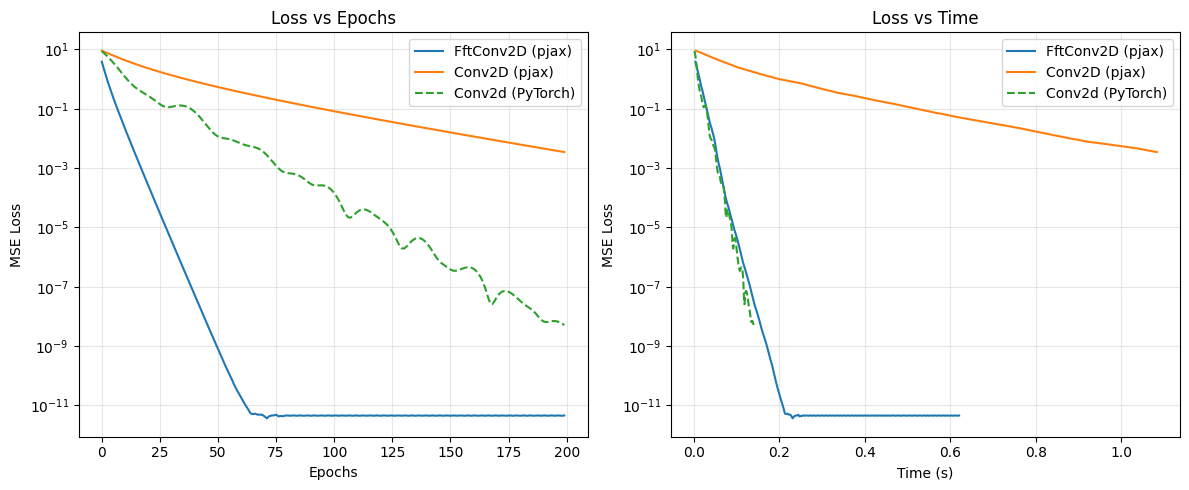

In [20]:
# 3. Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fft_losses, label='FftConv2D (pjax)')
plt.plot(reg_losses, label='Conv2D (pjax)')
plt.plot(torch_losses, label='Conv2d (PyTorch)', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.title('Loss vs Epochs')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(fft_times, fft_losses, label='FftConv2D (pjax)')
plt.plot(reg_times, reg_losses, label='Conv2D (pjax)')
plt.plot(torch_times, torch_losses, label='Conv2d (PyTorch)', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.title('Loss vs Time')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()